In [1]:
import tensorflow as tf
import keras
from keras import layers
import pickle
import numpy as np
import pandas as pd
import glob
import xarray as xr
from keras.models import load_model

from scipy.stats import norm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy
import cartopy.crs as ccrs

import shap
import warnings
warnings.filterwarnings("ignore")
from alibi.explainers import IntegratedGradients, KernelShap
import os
import scipy as sp
import scipy.ndimage
from matplotlib.transforms import Bbox
import matplotlib.patches as patches

In [2]:
def get_gradients(inputs, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    
    return grads

In [3]:
def get_integrated_gradients(inputs, baseline=None, num_steps=50, top_pred_idx=None):
    """Computes Integrated Gradients for a prediction.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        baseline (ndarray): The baseline image to start with for interpolation
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.            

    Returns:
        Integrated gradients w.r.t input image
    """
    # If baseline is not provided, start with zeros
    # having same size as the input image.
    if baseline is None:
        input_size = np.shape(inputs)[1:]
        baseline = np.zeros(input_size).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)

    # 1. Do interpolation.
    inputs = inputs.astype(np.float32)
    interpolated_inputs = [
        baseline + (step / num_steps) * (inputs - baseline)
        for step in range(num_steps + 1)
    ]
    interpolated_inputs = np.array(interpolated_inputs).astype(np.float32)

    # 3. Get the gradients
    grads = []
    for i, x_data in enumerate(interpolated_inputs):
        grad = get_gradients(x_data, top_pred_idx=top_pred_idx)     
        grads.append(grad)
    grads = tf.convert_to_tensor(grads, dtype=tf.float32)

    # 4. Approximate the integral using the trapezoidal rule
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    # 5. Calculate integrated gradients and return
    integrated_grads = (inputs - baseline) * avg_grads
    
    return integrated_grads

In [4]:
lat = np.arange(-90, 90, 180/192)
lon = np.arange(0, 360, 360/288)

lat_bnd1 = np.where(lat==10.3125)[0][0]
lat_bnd2 = np.where(lat==50.625)[0][0]
lon_bnd1 = np.where(lon==210)[0][0]
lon_bnd2 = np.where(lon==300)[0][0]

In [5]:
#set the base path 
base_path = '/sfs/weka/scratch/zkq5md'

#load the dataframe
df_se_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/SE_detrend_precip.csv', index_col='Unnamed: 0')
df_gp_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/GP_detrend_precip.csv', index_col='Unnamed: 0')
df_ca_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/CA_detrend_precip.csv', index_col='Unnamed: 0')
df_se_era5

,Datetimes,Maximum Precipitation,lats,lons
0,1950-01-01,29.729749,32.8125,266.25
1,1950-01-02,39.121912,35.6250,270.00
2,1950-01-03,18.399313,35.6250,266.25
3,1950-01-04,59.563390,35.6250,267.50
4,1950-01-05,40.699897,35.6250,271.25
...,...,...,...,...
9977,2015-12-27,75.272000,34.6875,266.25
9978,2015-12-28,51.817838,35.6250,267.50
9979,2015-12-29,26.021470,34.6875,276.25
9980,2015-12-30,44.338429,30.9375,271.25


In [6]:
with open(f'{base_path}/Data/ERA5/Final/X_era5.pkl', "rb") as f:
    x = pickle.load(f)
    
x = np.transpose(np.array(x), (0, 2, 3, 1))

x = x[:, lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2, :]

x_test_era5 = x[8000:]

y_se_era5_test = df_se_era5.iloc[8000:]
y_gp_era5_test = df_gp_era5.iloc[8000:]
y_ca_era5_test = df_ca_era5.iloc[8000:]

y_se_era5_test = y_se_era5_test.reset_index()
y_se_era5_test = y_se_era5_test.sample(n=200, random_state=41)

y_gp_era5_test = y_gp_era5_test.reset_index()
y_gp_era5_test = y_gp_era5_test.sample(n=200, random_state=41)

y_ca_era5_test = y_ca_era5_test.reset_index()
y_ca_era5_test = y_ca_era5_test.sample(n=200, random_state=41)

In [7]:
lat_bnd1_se = np.where(lat[lat_bnd1:lat_bnd2]==28.125)[0][0]
lat_bnd2_se = np.where(lat[lat_bnd1:lat_bnd2]==36.5625)[0][0]
lon_bnd1_se = np.where(lon[lon_bnd1:lon_bnd2]==266.25)[0][0]
lon_bnd2_se = np.where(lon[lon_bnd1:lon_bnd2]==280)[0][0]

lat_bnd1_gp = np.where(lat[lat_bnd1:lat_bnd2]==27.1875)[0][0]
lat_bnd2_gp = np.where(lat[lat_bnd1:lat_bnd2]==44.0625)[0][0]
lon_bnd1_gp = np.where(lon[lon_bnd1:lon_bnd2]==252.5)[0][0]
lon_bnd2_gp = np.where(lon[lon_bnd1:lon_bnd2]==263.75)[0][0]

lat_bnd1_ca = np.where(lat[lat_bnd1:lat_bnd2]==30.9375)[0][0]
lat_bnd2_ca = np.where(lat[lat_bnd1:lat_bnd2]==44.0625)[0][0]
lon_bnd1_ca = np.where(lon[lon_bnd1:lon_bnd2]==235)[0][0]
lon_bnd2_ca = np.where(lon[lon_bnd1:lon_bnd2]==246.25)[0][0]

In [8]:
locs = ['gp', 'se', 'ca']
model_types = ['mse', 'weight_mse', 'weight_mae']
model_type = 'mse'

for loc in locs:
    
    lat_bnd1 = locals()[f'lat_bnd1_{loc}']
    lat_bnd2 = locals()[f'lat_bnd2_{loc}']
    lon_bnd1 = locals()[f'lon_bnd1_{loc}']
    lon_bnd2 = locals()[f'lon_bnd2_{loc}']
    
    #for model_type in model_types:
    locals()[f'{model_type}_itg_{loc}_cwv'] = []
    locals()[f'{model_type}_itg_{loc}_z500'] = []
    locals()[f'{model_type}_itg_{loc}_tas'] = []
    

    for sample_id, sample in enumerate(locals()[f'y_{loc}_era5_test'].index.values):

        model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/post/{loc}_max_precip_{model_type}_model*')

        itgs = []

        for model_path in model_list:

            model_num = model_path.split('/')[-1].split('_')[-1].split('.')[0]

            if model_type == 'weight_mse':
                model = load_model(f"{model_path}", compile=False)

            else:
                model = load_model(f"{model_path}", safe_mode=False)

            itgs.append(get_integrated_gradients(np.expand_dims(x_test_era5[sample], 0)).numpy())
            
        print(f"{sample_id}, {loc}", end="\r")
        
        locals()[f'{model_type}_itg_{loc}_cwv'].append(np.sum(np.abs(np.mean(np.array(itgs), axis=0)[0,:,:,0])))
        locals()[f'{model_type}_itg_{loc}_z500'].append(np.sum(np.abs(np.mean(np.array(itgs), axis=0)[0,:,:,1])))
        locals()[f'{model_type}_itg_{loc}_tas'].append(np.sum(np.abs(np.mean(np.array(itgs), axis=0)[0,:,:,2])))

    
    locals()[f'y_{loc}_era5_test'][f'{model_type}_itg_cwv'] = locals()[f'{model_type}_itg_{loc}_cwv']
    locals()[f'y_{loc}_era5_test'][f'{model_type}_itg_z500'] = locals()[f'{model_type}_itg_{loc}_z500']
    locals()[f'y_{loc}_era5_test'][f'{model_type}_itg_tas'] = locals()[f'{model_type}_itg_{loc}_tas']
    
        

199, ca

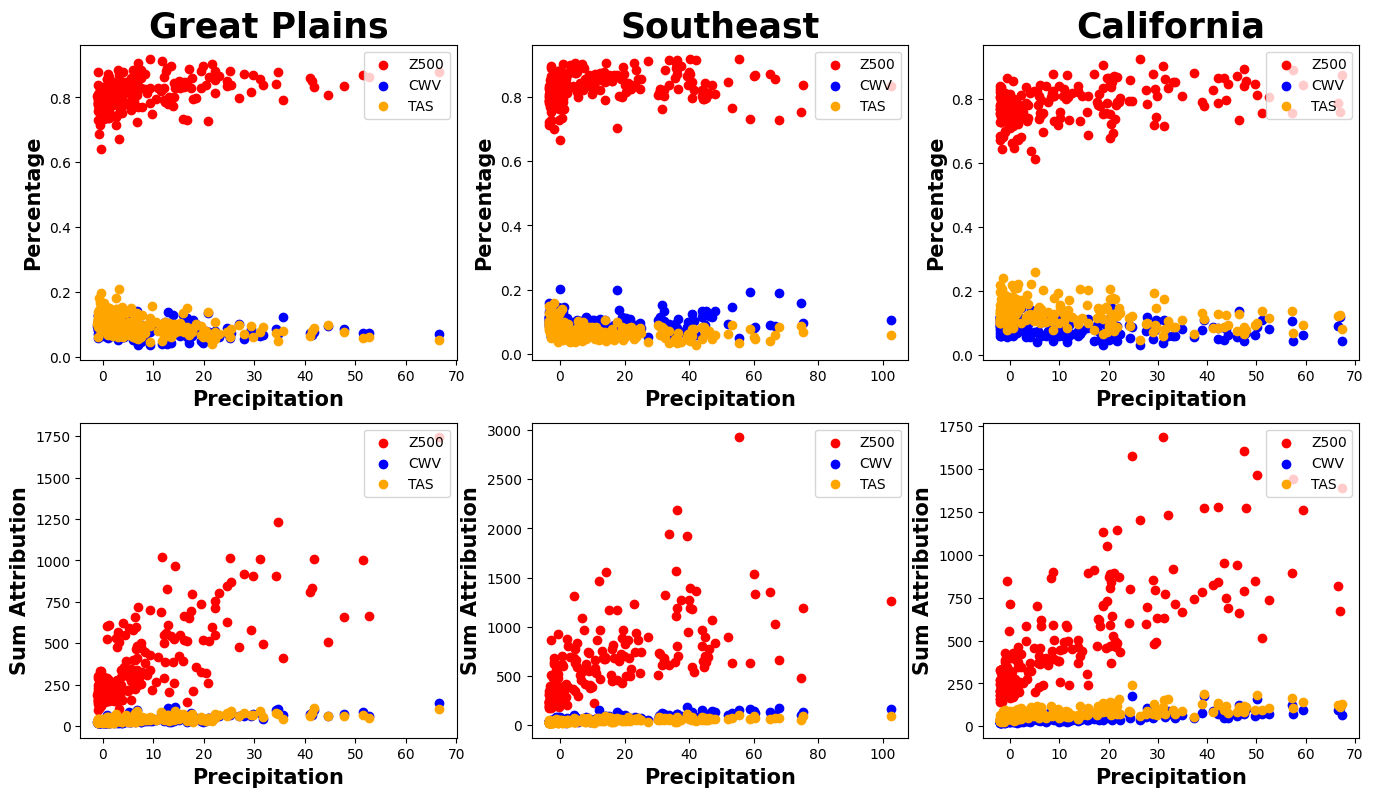

In [9]:
regions = ['Great Plains', 'Southeast', 'California']

fig = plt.figure(figsize=(16.5,9))
for num, loc in enumerate(locs):
    ax = plt.subplot(2,3,num+1) 
                     
    df = locals()[f'y_{loc}_era5_test'].sort_values(by='Maximum Precipitation')
    precip = df['Maximum Precipitation']
    
    itg_z500 = df['mse_itg_z500'].values
    itg_cwv = df['mse_itg_cwv'].values
    itg_tas = df['mse_itg_tas'].values
    
    itg_tot = itg_z500 + itg_cwv + itg_tas
    
    ax.scatter(precip, itg_z500/itg_tot, color="red")
    ax.scatter(precip, itg_cwv/itg_tot, color='blue')
    ax.scatter(precip, itg_tas/itg_tot, color='orange')

    ax.legend(['Z500', 'CWV', 'TAS'], fontsize=10, loc='upper right')
    ax.set_title(regions[num], fontsize=25, fontweight='bold')
    ax.set_ylabel('Percentage',fontsize=15, fontweight='bold')
    ax.set_xlabel('Precipitation',fontsize=15, fontweight='bold')

    ax = plt.subplot(2,3,num+4) 
                     
    df = locals()[f'y_{loc}_era5_test'].sort_values(by='Maximum Precipitation')
    precip = df['Maximum Precipitation']
    
    itg_z500 = df['mse_itg_z500'].values
    itg_cwv = df['mse_itg_cwv'].values
    itg_tas = df['mse_itg_tas'].values
    
    
    ax.scatter(precip, itg_z500, color="red")
    ax.scatter(precip, itg_cwv, color='blue')
    ax.scatter(precip, itg_tas, color='orange')

    ax.legend(['Z500', 'CWV', 'TAS'], fontsize=10, loc='upper right')
    ax.set_ylabel('Sum Attribution',fontsize=15, fontweight='bold')
    ax.set_xlabel('Precipitation',fontsize=15, fontweight='bold')

    plt.savefig(f'xai_contributions.png', format='png', dpi=500, bbox_inches='tight')
